In [1]:
import torch
import torchvision
import numpy
# import Pillow
import albumentations
import matplotlib
from tqdm import tqdm

In [59]:
# %%writefile Flicker_Data.py
import torch
import string
import os
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader
from PIL import Image

class Data(Dataset):
    def __init__(self, images_dir, captions_file):
        super(Data, self).__init__()
        self.images_dir = images_dir
        self.captions_file = captions_file
        self.ids, self.captions = self.read_captions()
        self.w2i, self.i2w, self.vocab = self.word_index()
        self.token = self.tokenizer()
        self.transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
        ])

    def read_captions(self):
        with open(self.captions_file, 'r') as f:
            lines = f.readlines()
        translator = str.maketrans('', '', string.punctuation)
        ids = [] 
        captions = {}
        for line in lines[1:]:
            new_id, new_caption = line.strip().split(',', 1)
            new_caption = '<START>' + ' ' + new_caption.lower().translate(translator) + ' ' + '<END>'
            if new_id in captions:
                captions[new_id].append(new_caption)
            else:
                captions[new_id] = [new_caption]
                ids.append(new_id)
        return ids, captions

    def word_index(self):
        captions = list(self.captions.values())
        original_vocab = set()
        for each_caption in captions:
            for sentence in each_caption:
                original_vocab = original_vocab.union(sentence.split())
        special_tokens = ["<START>", "<END>", "<PAD>"]
        rest_of_vocab = [word for word in original_vocab if word not in special_tokens]
        ordered_vocab = special_tokens + rest_of_vocab
        i2w = {i :j for i,j in enumerate(ordered_vocab)}
        w2i = {j :i for i,j in enumerate(ordered_vocab)}
        return w2i, i2w, ordered_vocab

    def tokenizer(self):
        max_length = max(len(caption.split()) for captions in self.captions.values() for caption in captions)
        token = {}
        for ids, captions in self.captions.items():
            token[ids] = [
            [self.w2i[word] for word in caption.split()] + (max_length-len(caption.split()))*[self.w2i['<PAD>']]
            for caption in captions
            ]
        return token 

    def image_reader(self, image_id):
        image_path = os.path.join(self.images_dir, image_id)
        image = Image.open(image_path).convert("RGB")
        return self.transform(image)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, ix):
        image_id = self.ids[ix]
        token = self.token[image_id]
        image = self.image_reader(image_id)
        caption = self.captions[image_id]
        return image_id, token, image, caption



def flicker_collate_fn(batch):
    # Unpack the batch
    image_ids, tokens, images, captions = zip(*batch)
    
    # Convert images to a tensor (already preprocessed in Data class)
    images = torch.stack(images, dim=0)
    
    # Convert padded tokens to a tensor
    tokens = torch.tensor(tokens, dtype=torch.long)
    
    # Return as a dictionary (adjust keys based on your model's input)
    return image_ids, tokens, images, captions

image_dir = '/home/shahmir/Desktop/Vision2words_ubuntu/Images'
caption_file = '/home/shahmir/Desktop/Vision2words_ubuntu/captions.txt'
data = Data(image_dir, caption_file)
Flicker8k_loader = DataLoader(data, batch_size = 64, shuffle = True, collate_fn = flicker_collate_fn)

Writing Flicker_Data.py


In [34]:
from Flicker_Data import Flicker8k_loader, data

ix, token, image, caption = next(iter(Flicker8k_loader))
image.shape, token.shape

(torch.Size([8, 3, 224, 224]),
 torch.Size([8, 5, 38]),
 torch.Size([8, 3, 224, 224]))

In [61]:
%%writefile model.py 
import torch
import torch.nn as nn 
from torchvision import models
import random
from Flicker_Data import Flicker8k_loader, data

class Captioner(nn.Module):
    def __init__(self, vocab_size, embedd_size, hidden_size, output_size, teacher_forcing_ratio=0.5):
        super(Captioner, self).__init__()
        self.teacher_forcing_ratio = teacher_forcing_ratio
        self.embedding_layer = nn.Embedding(vocab_size, embedd_size)
        
        efficientnet_b0 = models.efficientnet_b0(pretrained=True)
        for param in efficientnet_b0.features.parameters():
            param.requires_grad = False
        efficientnet_b0.features.eval()
        
        self.feature_extractor = nn.Sequential(
            efficientnet_b0.features,
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )
        self.reducer = nn.Linear(1280, embedd_size)
        self.lstm = nn.LSTM(embedd_size * 2, hidden_size, batch_first=True)  
        self.classifier = nn.Linear(hidden_size, output_size)
        
    def forward(self, image, token):
        batch_size, num_caption, seq_len = token.size()
        # print('Original:', token.shape, image.shape)
        features = self.feature_extractor(image)
        features = self.reducer(features)
        features = features.unsqueeze(1)
        features = features.expand(-1, num_caption, -1)
        features = features.reshape(batch_size * num_caption, -1)
        token = token.reshape(batch_size * num_caption, -1)
        embed_token = self.embedding_layer(token)
        # print('all_len: ', features.shape, embed_token.shape)
        # print(seq_len)
        features = features.unsqueeze(1)
        h, c = None, None
        all_token = []
        

        for t in range(seq_len):
            if t == 0:
                input_token = embed_token[:, t, :]
            else:
                use_teacher_forcing = random.random() < self.teacher_forcing_ratio
                if use_teacher_forcing:
                    input_token = embed_token[:, t, :]
                else:
                    input_token = self.embedding_layer(predicted_token.squeeze(-1))  
                    
            input_token = input_token.unsqueeze(1)
            # print(input_token.shape)
            # print(input_token.shape, features.shape)
            lstm_input = torch.cat([features, input_token], dim = 2)
            # print('lstm', lstm_input.shape)
            output, (h, c) = self.lstm(lstm_input, (h, c) if h is not None else None)
            output = output.squeeze(1)
            logits = self.classifier(output)
            all_token.append(logits)
            probs = torch.softmax(logits, dim = -1)
            predicted_token = torch.multinomial(probs, num_samples = 1)

        all_logits = torch.stack(all_token, dim=1)
        return all_logits
        



Overwriting model.py


In [46]:
vocab_size = len(data.vocab)
embedd_size = 32
hidden_size = 64
output_size = vocab_size
model = Captioner(vocab_size, embedd_size, hidden_size, output_size)


In [62]:
# %%writefile train.py
from Flicker_Data import Flicker8k_loader, data
from model import model
from tqdm import tqdm

import torch 
import torch.nn as nn 
import torch.optim as optim
num_epoch = int(input('num_epoch =' ))

vocab_size = len(data.vocab)  
criterion = nn.CrossEntropyLoss(ignore_index = 2)  
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
stepi = []; lossi=[]; counter = 0
for epoch in tqdm(range(num_epoch)):
    ix, token, image, caption = next(iter(Flicker8k_loader))
    optimizer.zero_grad()
    all_logits = model(image, token)
    all_logits = all_logits.view(-1, vocab_size)  
    targets = token.view(-1) 
    
    loss = criterion(all_logits, targets) 
    loss.backward()  
    optimizer.step()  
    counter += 1; lossi.append(loss.item()); stepi.append(counter)



Writing train.py


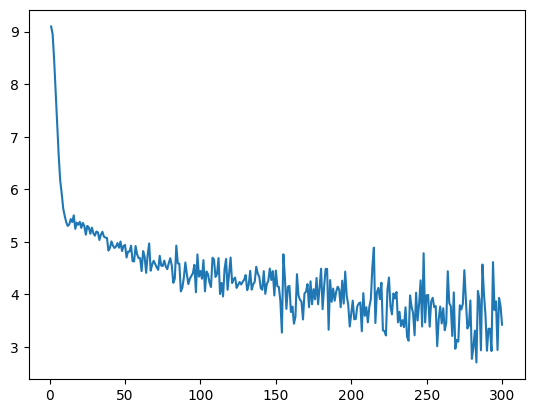

In [8]:
import matplotlib.pyplot as plt 
plt.plot(stepi, lossi)

(torch.Size([1520, 8831]), torch.Size([1520]))

In [64]:
%%writefile inference.py
from Flicker_Data import Flicker8k_loader, data
from model import model
import torch
import matplotlib.pyplot as plt

def inference_with_multinomial(model, image, start_token, end_token, max_seq_len=20, temperature=1.3):
    model.eval()  
    device = next(model.parameters()).device 
    image = image.to(device)  
    caption = [start_token]
    with torch.no_grad():  
        features = model.feature_extractor(image)
        features = model.reducer(features)
        features = features.unsqueeze(1)  # Shape: (1, 1, embedd_size)

        h, c = None, None

        for t in range(max_seq_len):
            input_token = torch.tensor([caption[-1]], device=device).unsqueeze(0)  
            input_token = model.embedding_layer(input_token)  

            lstm_input = torch.cat([features, input_token], dim=2)
            output, (h, c) = model.lstm(lstm_input, (h, c) if h is not None else None)
            logits = model.classifier(output.squeeze(1))  # Shape: (1, vocab_size)
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)  
            predicted_token = torch.multinomial(probs, num_samples=1).item()  # Shape: (1,)
            caption.append(predicted_token)
            if predicted_token == end_token:
                break

    return caption

ix, token, image, caption = next(iter(Flicker8k_loader))
caption = inference_with_multinomial(model, image[0].unsqueeze_(0), 0, 1)
generated_caption = [data.i2w[token] for token in caption]
print("Generated Caption:", " ".join(generated_caption))
plt.imshow(image[0].permute(1, 2, 0))
plt.show()
###

Overwriting inference.py


In [ ]:
# from torchsummary import summary 
from torchinfo import summary 
summary(model, input_size=[(1, 3, 224, 224), (1, 5, 38)], dtypes=[torch.float, torch.long])